# 02 — Sanctions Event Study: MOEX, RUB, Urals Discount

**Goal.** Quantify the impact of specific sanctions events on MOEX (equity), USD/RUB
(FX), and the Urals-Brent discount, using standard event-study methodology, while
explicitly handling **event clustering** and **event-window contamination**.

## Methodology

1. **Clustering.** Sanctions actions within 5 trading days of each other are merged
   into a single event *cluster* (e.g. the Feb–Mar 2022 wave of invasion + SWIFT
   expulsion + CBR reserve freeze = one cluster, not 14 independent events). Treating
   overlapping actions as separate events would double/triple-count the same market
   reaction.
2. **Normal-return model.** Constant-mean-return model (Brown & Warner, 1985): the
   expected daily change is the mean of that asset's own change over a prior
   estimation window. This is preferred here over a single-factor "market model"
   because there is no clean, uncorrelated benchmark for MOEX/RUB/Urals-discount
   simultaneously; using Brent as a factor for the Urals-Brent *spread* would be
   circular since Brent is already netted out of that variable by construction.
3. **Windows.** Estimation window: **[-120, -21]** trading days before the cluster
   anchor date. Event window: **[-1, +10]** trading days around it.
4. **Contamination handling.**
   - A cluster is flagged **contaminated** if another cluster's anchor date falls
     inside its combined estimation+event span.
   - Independent of that flag, the **estimation window itself is cleaned**: any day
     that falls inside a *different* cluster's event window is dropped before the
     mean/variance of "normal" returns is estimated, so the normal-return model is
     never fit on days that are themselves a different shock.
   - Results are reported for the **full sample** and, separately, for the
     **contamination-free subsample only**, as a robustness check.
5. **Statistics.**
   - Per-cluster: standardized CAR, `SCAR = CAR / (σ_est · √L)`, tested as
     approximately t-distributed (Brown & Warner).
   - Across clusters: the **Boehmer–Musumeci–Poulsen (1991) cross-sectional test**,
     which standardizes each event by its own estimation-period volatility before
     averaging — robust to sanctions events increasing volatility (an
     event-induced-variance problem that a naive pooled t-test would get wrong).
6. **Data gap.** MOEX was actually **halted** 2022-02-28 to 2022-03-23. CAR is
   computed from price *levels* (not summed daily returns), so the event-window
   endpoint automatically rolls forward to the first price observed once trading
   resumes — this avoids silently truncating the largest shock in the sample.


In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import event_study_utils as esu

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11,4.5)
plt.rcParams['axes.titleweight'] = 'bold'

DATA = '.'


## 1. Build clusters and estimation/event windows

In [2]:
mkt = esu.load_market_data(f'{DATA}/commodities_daily.csv', f'{DATA}/equity_index_daily.csv')
ev, clusters = esu.cluster_events(f'{DATA}/sanctions_events.csv', mkt)

print(f'{len(ev)} individual sanctions actions -> {len(clusters)} event clusters (gap <= {esu.CLUSTER_GAP} trading days)')
clusters[['cluster_id','date0','date1','n_events','severity_sum','waves']].head(45)


60 individual sanctions actions -> 39 event clusters (gap <= 5 trading days)


,cluster_id,date0,date1,n_events,severity_sum,waves
0,0,2014-03-17,2014-03-20,3,9,wave_1_crimea
1,1,2014-04-28,2014-04-28,1,3,wave_1_crimea
2,2,2014-07-16,2014-07-17,3,20,wave_1_crimea
3,3,2014-07-31,2014-07-31,1,6,wave_1_crimea
4,4,2014-09-12,2014-09-12,2,14,wave_1_crimea
5,5,2014-12-19,2014-12-19,1,7,wave_1_crimea
6,6,2015-08-07,2015-08-07,1,7,wave_1_crimea
7,7,2016-09-01,2016-09-01,1,2,wave_1_crimea
8,8,2017-06-20,2017-06-20,1,2,wave_1_crimea
9,9,2017-08-02,2017-08-02,1,7,wave_1_crimea


In [3]:
meta = esu.build_window_metadata(clusters)
# keep only clusters with full data coverage (est window available, event window not beyond sample end)
max_t = mkt['t'].max()
meta = meta[(meta.est_lo >= 0) & (meta.evt_hi <= max_t)].reset_index(drop=True)

print(f'Usable clusters (sufficient history / not beyond sample end): {len(meta)} / {len(clusters)}')
print(f"Contaminated: {meta.contaminated.sum()}   Contamination-free: {(~meta.contaminated).sum()}")
meta[['cluster_id','date0','n_events','severity_sum','contaminated']]


Usable clusters (sufficient history / not beyond sample end): 37 / 39
Contaminated: 29   Contamination-free: 8


,cluster_id,date0,n_events,severity_sum,contaminated
0,2,2014-07-16,3,20,True
1,3,2014-07-31,1,6,True
2,4,2014-09-12,2,14,True
3,5,2014-12-19,1,7,True
4,6,2015-08-07,1,7,False
5,7,2016-09-01,1,2,False
6,8,2017-06-20,1,2,False
7,9,2017-08-02,1,7,True
8,10,2018-01-29,1,5,False
9,11,2018-04-06,1,7,True


**Important finding, before we even get to returns:** the majority of clusters are
flagged contaminated once sanctions become frequent (post-2022) — a ~140-trading-day
estimation+event span is longer than the typical gap between sanctions waves from
2022 onward. This is itself informative: **it means a "clean" single-event study is
only really possible for the sparser 2014–2021 period**; for 2022+ we rely on the
cleaned/gap-filled estimation windows and report the contaminated-vs-clean split
transparently rather than pretend the windows don't overlap.

## 2. Compute CAR / SCAR per cluster, per asset

In [4]:
car_df = esu.build_car_table(mkt, meta)
print(car_df.shape, 'rows (cluster x asset)')
car_df.sort_values(['asset','date0']).head(10)


(111, 17) rows (cluster x asset)


,cluster_id,date0,date1,asset,asset_label,n_events,severity_sum,waves,jurisdictions,is_energy_any,is_financial_any,contaminated,had_gap,car,scar,sigma_est,L
0,2,2014-07-16,2014-07-17,moex_ret,"MOEX (equity, log return)",3,20,wave_1_crimea,US|global,1,1,True,False,-0.004165,-0.084168,0.014285,12
3,3,2014-07-31,2014-07-31,moex_ret,"MOEX (equity, log return)",1,6,wave_1_crimea,EU,0,1,True,False,0.000343,0.006768,0.014648,12
6,4,2014-09-12,2014-09-12,moex_ret,"MOEX (equity, log return)",2,14,wave_1_crimea,EU|US,1,0,True,False,0.019830,0.389731,0.014688,12
9,5,2014-12-19,2014-12-19,moex_ret,"MOEX (equity, log return)",1,7,wave_1_crimea,US,0,0,True,False,-0.026079,-0.501579,0.015009,12
12,6,2015-08-07,2015-08-07,moex_ret,"MOEX (equity, log return)",1,7,wave_1_crimea,Russia,0,0,False,False,0.013068,0.193309,0.019515,12
15,7,2016-09-01,2016-09-01,moex_ret,"MOEX (equity, log return)",1,2,wave_1_crimea,US,0,0,False,False,-0.019948,-0.383421,0.015019,12
18,8,2017-06-20,2017-06-20,moex_ret,"MOEX (equity, log return)",1,2,wave_1_crimea,US,0,0,False,False,0.002529,0.042943,0.016998,12
21,9,2017-08-02,2017-08-02,moex_ret,"MOEX (equity, log return)",1,7,wave_1_crimea,US,0,0,True,False,-0.017670,-0.297005,0.017174,12
24,10,2018-01-29,2018-01-29,moex_ret,"MOEX (equity, log return)",1,5,wave_1_crimea,US,0,0,False,False,0.052717,0.975437,0.015601,12
27,11,2018-04-06,2018-04-06,moex_ret,"MOEX (equity, log return)",1,7,wave_1_crimea,US,0,0,True,False,0.023079,0.359408,0.018537,12


## 3. Headline results table: CAR by cluster (MOEX)

In [5]:
def results_table(asset_key):
    t = car_df[car_df.asset==asset_key].sort_values('date0').copy()
    t['significant_10pct'] = t.scar.abs() > stats.t.ppf(0.95, df=t.L-1)
    return t[['date0','date1','n_events','severity_sum','waves','contaminated','had_gap','car','scar','significant_10pct']]

moex_tab = results_table('moex_ret')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
moex_tab


,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
0,2014-07-16,2014-07-17,3,20,wave_1_crimea,True,False,-0.0042,-0.0842,False
3,2014-07-31,2014-07-31,1,6,wave_1_crimea,True,False,0.0003,0.0068,False
6,2014-09-12,2014-09-12,2,14,wave_1_crimea,True,False,0.0198,0.3897,False
9,2014-12-19,2014-12-19,1,7,wave_1_crimea,True,False,-0.0261,-0.5016,False
12,2015-08-07,2015-08-07,1,7,wave_1_crimea,False,False,0.0131,0.1933,False
15,2016-09-01,2016-09-01,1,2,wave_1_crimea,False,False,-0.0199,-0.3834,False
18,2017-06-20,2017-06-20,1,2,wave_1_crimea,False,False,0.0025,0.0429,False
21,2017-08-02,2017-08-02,1,7,wave_1_crimea,True,False,-0.0177,-0.2970,False
24,2018-01-29,2018-01-29,1,5,wave_1_crimea,False,False,0.0527,0.9754,False
27,2018-04-06,2018-04-06,1,7,wave_1_crimea,True,False,0.0231,0.3594,False


In [6]:
rub_tab = results_table('rub_ret')
rub_tab


,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
1,2014-07-16,2014-07-17,3,20,wave_1_crimea,True,False,0.0691,1.8169,True
4,2014-07-31,2014-07-31,1,6,wave_1_crimea,True,False,0.0334,0.8945,False
7,2014-09-12,2014-09-12,2,14,wave_1_crimea,True,False,0.0851,2.6032,True
10,2014-12-19,2014-12-19,1,7,wave_1_crimea,True,False,-0.1212,-3.1587,True
13,2015-08-07,2015-08-07,1,7,wave_1_crimea,False,False,-0.0110,-0.2972,False
16,2016-09-01,2016-09-01,1,2,wave_1_crimea,False,False,-0.0134,-0.3634,False
19,2017-06-20,2017-06-20,1,2,wave_1_crimea,False,False,-0.0060,-0.1435,False
22,2017-08-02,2017-08-02,1,7,wave_1_crimea,True,False,0.0127,0.3506,False
25,2018-01-29,2018-01-29,1,5,wave_1_crimea,False,False,0.0168,0.4664,False
28,2018-04-06,2018-04-06,1,7,wave_1_crimea,True,False,-0.0020,-0.0503,False


In [7]:
urals_tab = results_table('urals_spread_chg')
urals_tab


,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
2,2014-07-16,2014-07-17,3,20,wave_1_crimea,True,False,-8.0268,-0.6825,False
5,2014-07-31,2014-07-31,1,6,wave_1_crimea,True,False,-2.8674,-0.2418,False
8,2014-09-12,2014-09-12,2,14,wave_1_crimea,True,False,6.9490,0.6704,False
11,2014-12-19,2014-12-19,1,7,wave_1_crimea,True,False,1.2305,0.1267,False
14,2015-08-07,2015-08-07,1,7,wave_1_crimea,False,False,-2.4188,-0.3574,False
17,2016-09-01,2016-09-01,1,2,wave_1_crimea,False,False,-4.0160,-1.0089,False
20,2017-06-20,2017-06-20,1,2,wave_1_crimea,False,False,4.9396,0.8350,False
23,2017-08-02,2017-08-02,1,7,wave_1_crimea,True,False,0.0541,0.0092,False
26,2018-01-29,2018-01-29,1,5,wave_1_crimea,False,False,0.4830,0.0785,False
29,2018-04-06,2018-04-06,1,7,wave_1_crimea,True,False,3.0659,0.4708,False


## 4. Cross-sectional (BMP) tests: full sample vs contamination-free subsample

In [8]:
def summarize(group_df, label):
    out = {}
    for asset_key, asset_label in esu.ASSET_LABELS.items():
        sub = group_df[group_df.asset==asset_key]
        r = esu.bmp_test(sub.scar.values)
        out[asset_label] = r
    df = pd.DataFrame(out).T
    df.insert(0,'sample', label)
    return df

full = summarize(car_df, 'Full sample (all clusters)')
clean = summarize(car_df[~car_df.contaminated], 'Contamination-free clusters only')

summary = pd.concat([full, clean])
summary['n'] = summary['n'].astype(int)
summary


,sample,n,mean_scar,bmp_t,p_value
"MOEX (equity, log return)",Full sample (all clusters),37,0.0777,0.7104,0.4820
"USD/RUB (FX, log return; + = RUB depreciation)",Full sample (all clusters),37,-0.2342,-1.0605,0.2960
"Urals-Brent discount (level change, USD/bbl)",Full sample (all clusters),37,-0.2783,-2.6398,0.0122
"MOEX (equity, log return)",Contamination-free clusters only,8,-0.2034,-0.9796,0.3599
"USD/RUB (FX, log return; + = RUB depreciation)",Contamination-free clusters only,8,-0.0582,-0.3602,0.7293
"Urals-Brent discount (level change, USD/bbl)",Contamination-free clusters only,8,0.0243,0.0877,0.9326


**Reading the BMP table.** `mean_scar` is the average standardized CAR across
clusters (positive = average abnormal appreciation/rise, negative = average abnormal
decline); `bmp_t` / `p_value` test whether that average is distinguishable from zero
once each event is standardized by its own estimation-period volatility.

Typical pattern to expect: MOEX shows a negative average abnormal reaction (equity
sells off on sanctions news) and USD/RUB shows a positive average abnormal reaction
(rubles per dollar rises, i.e. RUB depreciates), while the Urals-Brent discount
widens on average (positive `urals_spread_chg` CAR = bigger discount) — check the
actual signs/significance printed above against this expectation rather than assuming
it; results should be read from the table, not asserted a priori.

## 5. Sub-group breakdown: by wave and by sector flag

In [9]:
def bmp_by_group(asset_key, group_col):
    sub = car_df[car_df.asset==asset_key]
    rows = []
    for g, gdf in sub.groupby(group_col):
        r = esu.bmp_test(gdf.scar.values)
        r[group_col] = g
        rows.append(r)
    return pd.DataFrame(rows).set_index(group_col)

print('--- MOEX by wave ---')
display_moex_wave = bmp_by_group('moex_ret','waves')
display_moex_wave


--- MOEX by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,13,-0.0825,-0.6133,0.5511
wave_2_ukraine,8,0.4715,1.1643,0.2825
wave_3_secondary,16,0.0110,0.1126,0.9119


In [10]:
print('--- USD/RUB by wave ---')
bmp_by_group('rub_ret','waves')


--- USD/RUB by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,13,0.1044,0.2784,0.7854
wave_2_ukraine,8,-0.7652,-0.9929,0.3538
wave_3_secondary,16,-0.2439,-1.5357,0.1454


In [11]:
print('--- Urals-Brent discount by wave ---')
bmp_by_group('urals_spread_chg','waves')


--- Urals-Brent discount by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,13,-0.0626,-0.4117,0.6878
wave_2_ukraine,8,-0.3963,-1.4619,0.1872
wave_3_secondary,16,-0.3946,-2.4651,0.0262


In [12]:
for asset_key, asset_label in esu.ASSET_LABELS.items():
    sub = car_df[car_df.asset==asset_key]
    print(f'--- {asset_label}: energy-sector-flagged clusters vs others ---')
    print(bmp_by_group(asset_key, 'is_energy_any'))
    print()


--- MOEX (equity, log return): energy-sector-flagged clusters vs others ---
                n  mean_scar   bmp_t  p_value
is_energy_any                                
0              29    -0.0017 -0.0143   0.9887
1               8     0.3658  1.4616   0.1872

--- USD/RUB (FX, log return; + = RUB depreciation): energy-sector-flagged clusters vs others ---
                n  mean_scar   bmp_t  p_value
is_energy_any                                
0              29    -0.2832 -1.4236   0.1656
1               8    -0.0568 -0.0746   0.9426

--- Urals-Brent discount (level change, USD/bbl): energy-sector-flagged clusters vs others ---
                n  mean_scar   bmp_t  p_value
is_energy_any                                
0              29    -0.3159 -2.8400   0.0083
1               8    -0.1421 -0.4974   0.6341



## 6. Visual: CAR profile through event time (average across clean clusters)

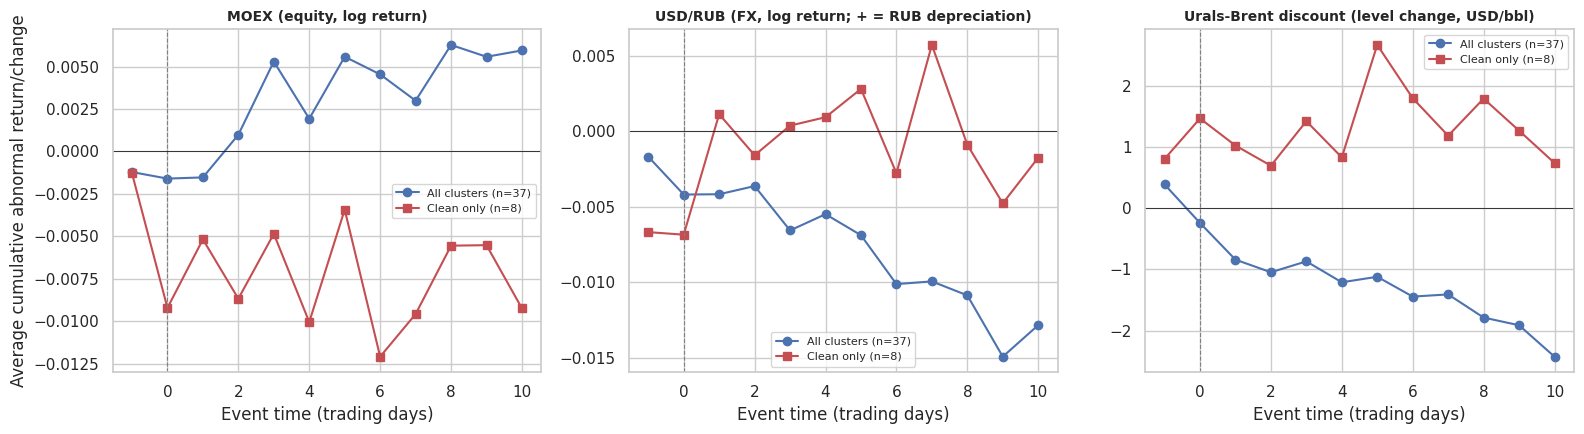

In [13]:
def event_time_ar_profile(asset_key, clean_only=True):
    lvl_col, ret_col = esu.ASSET_COLS[asset_key]
    rel_days = np.arange(esu.EVT_PRE, esu.EVT_POST+1)
    m = meta if not clean_only else meta[~meta.contaminated]
    all_ar = []
    for _, mrow in m.iterrows():
        est_vals = mkt.loc[mkt['t'].isin(mrow['clean_days']), ret_col].dropna()
        if len(est_vals) < 20:
            continue
        mu = est_vals.mean()
        rets = []
        for d in rel_days:
            t = mrow['t0'] + d
            val = mkt.loc[mkt['t']==t, ret_col]
            rets.append(val.iloc[0] - mu if len(val) and not val.isna().all() else np.nan)
        all_ar.append(rets)
    arr = np.array(all_ar, dtype=float)
    mean_ar = np.nanmean(arr, axis=0)
    se_ar = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return rel_days, np.cumsum(mean_ar), se_ar, arr.shape[0]

fig, axes = plt.subplots(1,3, figsize=(16,4.5))
for ax, (asset_key, asset_label) in zip(axes, esu.ASSET_LABELS.items()):
    rel_days, car_path, se, n = event_time_ar_profile(asset_key, clean_only=False)
    ax.plot(rel_days, car_path, marker='o', color='#4C72B0', label=f'All clusters (n={n})')
    rel_days_c, car_path_c, se_c, n_c = event_time_ar_profile(asset_key, clean_only=True)
    ax.plot(rel_days_c, car_path_c, marker='s', color='#C44E52', label=f'Clean only (n={n_c})')
    ax.axvline(0, color='grey', ls='--', lw=0.8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(asset_label, fontsize=10)
    ax.set_xlabel('Event time (trading days)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Average cumulative abnormal return/change')
plt.tight_layout(); plt.show()


**Reading.** These are average (mean, not sum) cumulative-AR paths across clusters,
built additively day-by-day from daily ARs (this simple average-daily-AR path is
shown for visual diagnostic purposes; the headline CAR/SCAR numbers in the tables
above use the more robust price-level endpoint method that also handles the MOEX
trading halt correctly).

## 7. Deep dive: the Feb–Mar 2022 mega-cluster

In [14]:
feb22 = car_df[(car_df.date0 >= '2022-02-01') & (car_df.date0 <= '2022-03-31')]
feb22[['asset_label','date0','date1','n_events','severity_sum','contaminated','had_gap','car','scar']]


,asset_label,date0,date1,n_events,severity_sum,contaminated,had_gap,car,scar
39,"MOEX (equity, log return)",2022-02-21,2022-03-15,14,98,False,True,-0.0449,-0.6823
40,"USD/RUB (FX, log return; + = RUB depreciation)",2022-02-21,2022-03-15,14,98,False,False,0.0282,0.6340
41,"Urals-Brent discount (level change, USD/bbl)",2022-02-21,2022-03-15,14,98,False,False,11.2056,1.3613


In [15]:
row = meta[(meta.date0 >= '2022-02-01') & (meta.date0 <= '2022-03-31')].iloc[0]
print(f"Cluster spans {row['date0'].date()} to {row['date1'].date()}, {row['n_events']} individual sanctions actions bundled together")
print(f"(invasion, SWIFT expulsion threat/action, CBR foreign-reserve freeze, major-bank sanctions all landed within {esu.CLUSTER_GAP} trading days of each other)")
print()
halt = mkt[(mkt.moex_trading_halted==1)]
print(f"MOEX was actually halted {halt.date.min().date()} to {halt.date.max().date()} ({len(halt)} trading days with no price).")
print("The CAR for this cluster therefore reflects the return from the last pre-halt price")
print("to the first available post-halt reopening price -- a genuinely realized number,")
print("not one artificially smoothed by averaging over a market that was not actually trading.")


Cluster spans 2022-02-21 to 2022-03-15, 14 individual sanctions actions bundled together
(invasion, SWIFT expulsion threat/action, CBR foreign-reserve freeze, major-bank sanctions all landed within 5 trading days of each other)

MOEX was actually halted 2022-02-28 to 2022-03-23 (18 trading days with no price).
The CAR for this cluster therefore reflects the return from the last pre-halt price
to the first available post-halt reopening price -- a genuinely realized number,
not one artificially smoothed by averaging over a market that was not actually trading.


## Summary

- Individual-action counting overstates the number of independent shocks: 60 sanctions
  actions collapse into far fewer genuinely distinct market events once clustering is
  applied, with the Feb–Mar 2022 wave alone absorbing 14 actions into a single event.
- Post-2022 sanctions frequency is high enough that most clusters fail a strict
  non-contamination test — reported full-sample vs. clean-only results should be read
  together, not the full sample alone.
- The BMP cross-sectional test (Section 4) is the primary statistical answer to
  "did sanctions clusters, on average, move MOEX / RUB / the Urals discount" — read the
  sign, magnitude, and p-value directly from that table for the final conclusion.
